# PRODIGY_DS_02 — Data Cleaning & EDA (Titanic)
**Prodigy InfoTech — Data Science Internship, Task 02**

Task: Perform data cleaning and exploratory data analysis (EDA) on a dataset of your choice, such as the Titanic dataset from Kaggle. Explore the relationships between variables and identify patterns and trends in the data.

## 1. Import libraries & load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

!wget -q -O titanic.csv https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv
df = pd.read_csv("titanic.csv")
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Inspect missing values & duplicates

In [2]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB
None

Missing values:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Duplicate ro

## 3. Data Cleaning
- **`deck`**: ~77% missing → drop the column entirely (too sparse to impute)
- **`age`**: ~20% missing → impute with the **median age within each passenger class** (more realistic than a single global median)
- **`embarked` / `embark_town`**: only 2 missing → drop those rows
- **Duplicates**: this dataset has no unique passenger ID, so identical rows may just be coincidental matches — reported but kept

In [3]:
df = df.drop(columns=["deck"])
df["age"] = df.groupby("class")["age"].transform(lambda x: x.fillna(x.median()))
df = df.dropna(subset=["embarked", "embark_town"])

print("Missing values remaining:", df.isnull().sum().sum())
print("Final shape:", df.shape)

Missing values remaining: 0
Final shape: (889, 14)


## 4. Survival rate by class
First-class passengers survived at a much higher rate than third class.

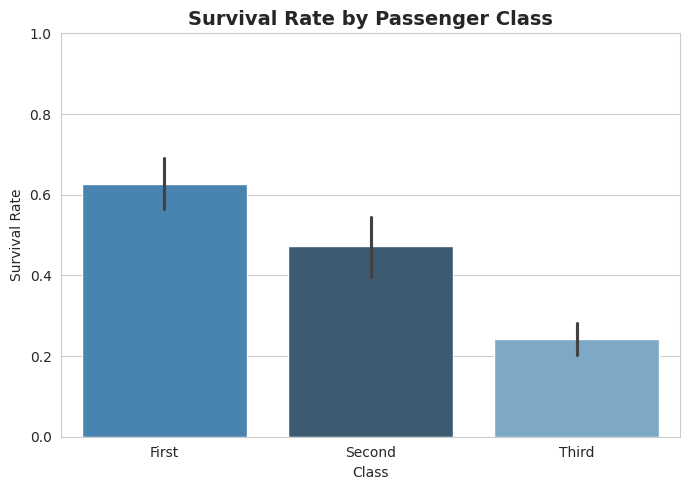

In [4]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="class", y="survived", hue="class", order=["First", "Second", "Third"], palette="Blues_d", legend=False)
plt.title("Survival Rate by Passenger Class", fontsize=14, fontweight="bold")
plt.ylabel("Survival Rate"); plt.xlabel("Class"); plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("survival_by_class.png", dpi=150)
plt.show()

## 5. Survival rate by gender

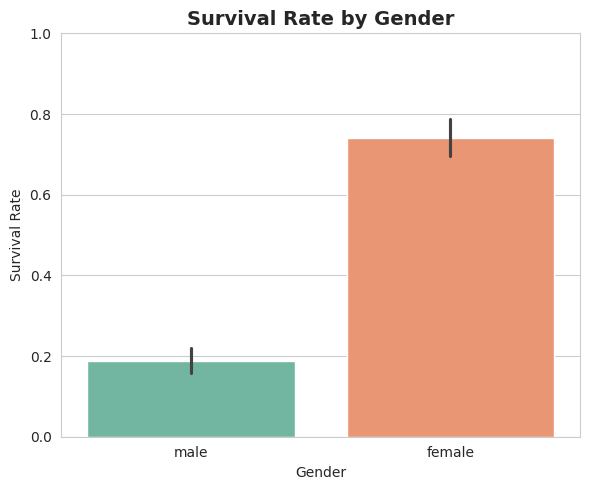

In [5]:
plt.figure(figsize=(6, 5))
sns.barplot(data=df, x="sex", y="survived", hue="sex", palette="Set2", legend=False)
plt.title("Survival Rate by Gender", fontsize=14, fontweight="bold")
plt.ylabel("Survival Rate"); plt.xlabel("Gender"); plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("survival_by_gender.png", dpi=150)
plt.show()

## 6. Age distribution by survival outcome

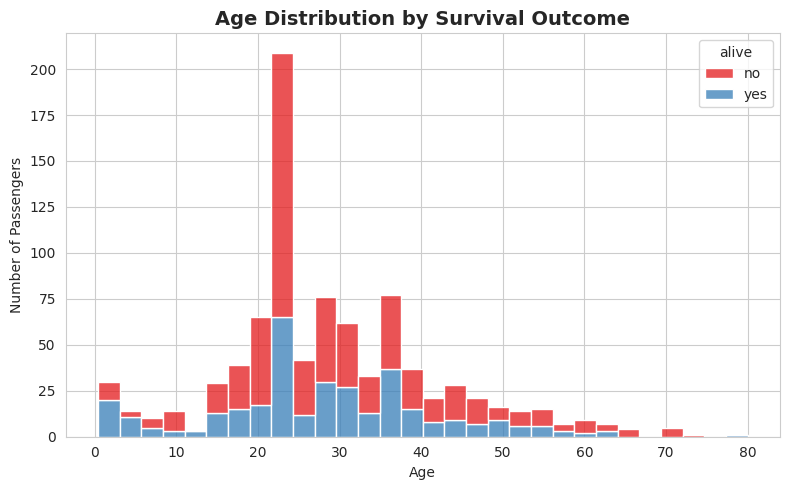

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", hue="alive", multiple="stack", bins=30, palette="Set1")
plt.title("Age Distribution by Survival Outcome", fontsize=14, fontweight="bold")
plt.xlabel("Age"); plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.savefig("age_distribution_by_survival.png", dpi=150)
plt.show()

## 7. Fare distribution by class

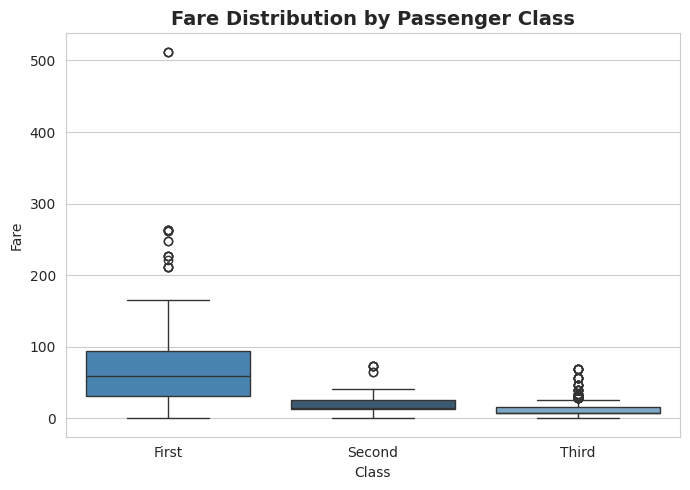

In [7]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="class", y="fare", hue="class", order=["First", "Second", "Third"], palette="Blues_d", legend=False)
plt.title("Fare Distribution by Passenger Class", fontsize=14, fontweight="bold")
plt.ylabel("Fare"); plt.xlabel("Class")
plt.tight_layout()
plt.savefig("fare_by_class.png", dpi=150)
plt.show()

## 8. Survival rate by class AND gender combined
The classic Titanic pattern — class and gender compound rather than act independently.

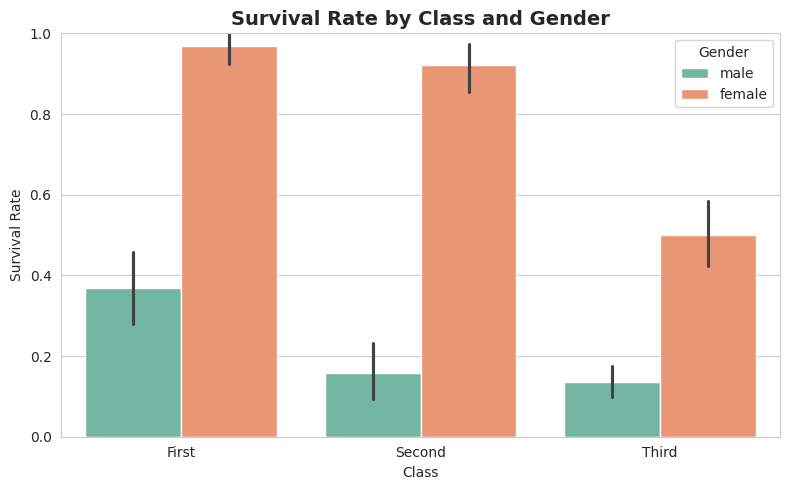

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="class", y="survived", hue="sex", order=["First", "Second", "Third"], palette="Set2")
plt.title("Survival Rate by Class and Gender", fontsize=14, fontweight="bold")
plt.ylabel("Survival Rate"); plt.xlabel("Class"); plt.ylim(0, 1)
plt.legend(title="Gender")
plt.tight_layout()
plt.savefig("survival_by_class_and_gender.png", dpi=150)
plt.show()

## 9. Correlation heatmap

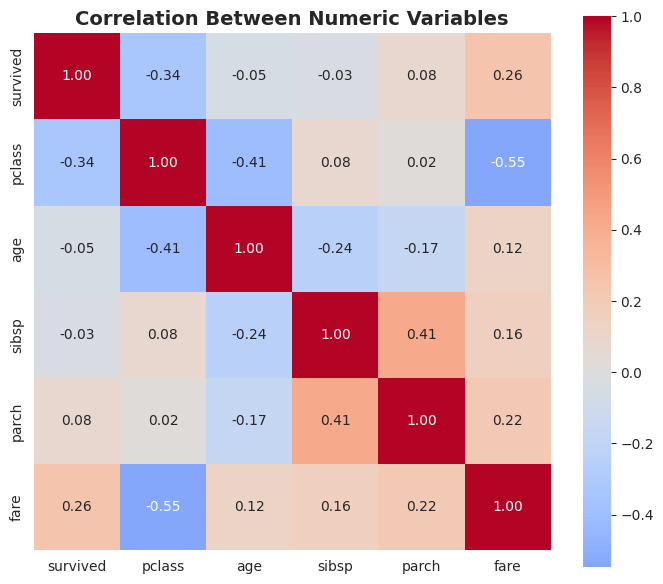

In [9]:
numeric_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Between Numeric Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

## 10. Key Findings
- **Overall survival rate: 38.2%**
- **By class:** First 62.6% → Second 47.3% → Third 24.2%
- **By gender:** Female 74.0% vs. Male 18.9% — the strongest single pattern
- **Combined:** First-class women survived at ~97%, third-class men at ~14% — class and gender compound together
- **Correlations:** `pclass` negatively correlates with survival (-0.34), `fare` positively (+0.26)

These findings reflect the "women and children first" evacuation policy combined with unequal lifeboat access across classes.

---
*Part of the Data Science Internship @ Prodigy InfoTech (Oct 2026)* #ProdigyInfoTech